DIABETES PREDICTION - DATA EXPLORATION

Dataset Shape: (100000, 9)

First 5 rows:
    gender   age  hypertension  heart_disease smoking_history    bmi  \
0  Female  80.0             0              1           never  25.19   
1  Female  54.0             0              0         No Info  27.32   
2    Male  28.0             0              0           never  27.32   
3  Female  36.0             0              0         current  23.45   
4    Male  76.0             1              1         current  20.14   

   HbA1c_level  blood_glucose_level  diabetes  
0          6.6                  140         0  
1          6.6                   80         0  
2          5.7                  158         0  
3          5.0                  155         0  
4          4.8                  155         0  

Dataset Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100000 entries, 0 to 99999
Data columns (total 9 columns):
 #   Column               Non-Null Count   Dtype  
---  ------               -

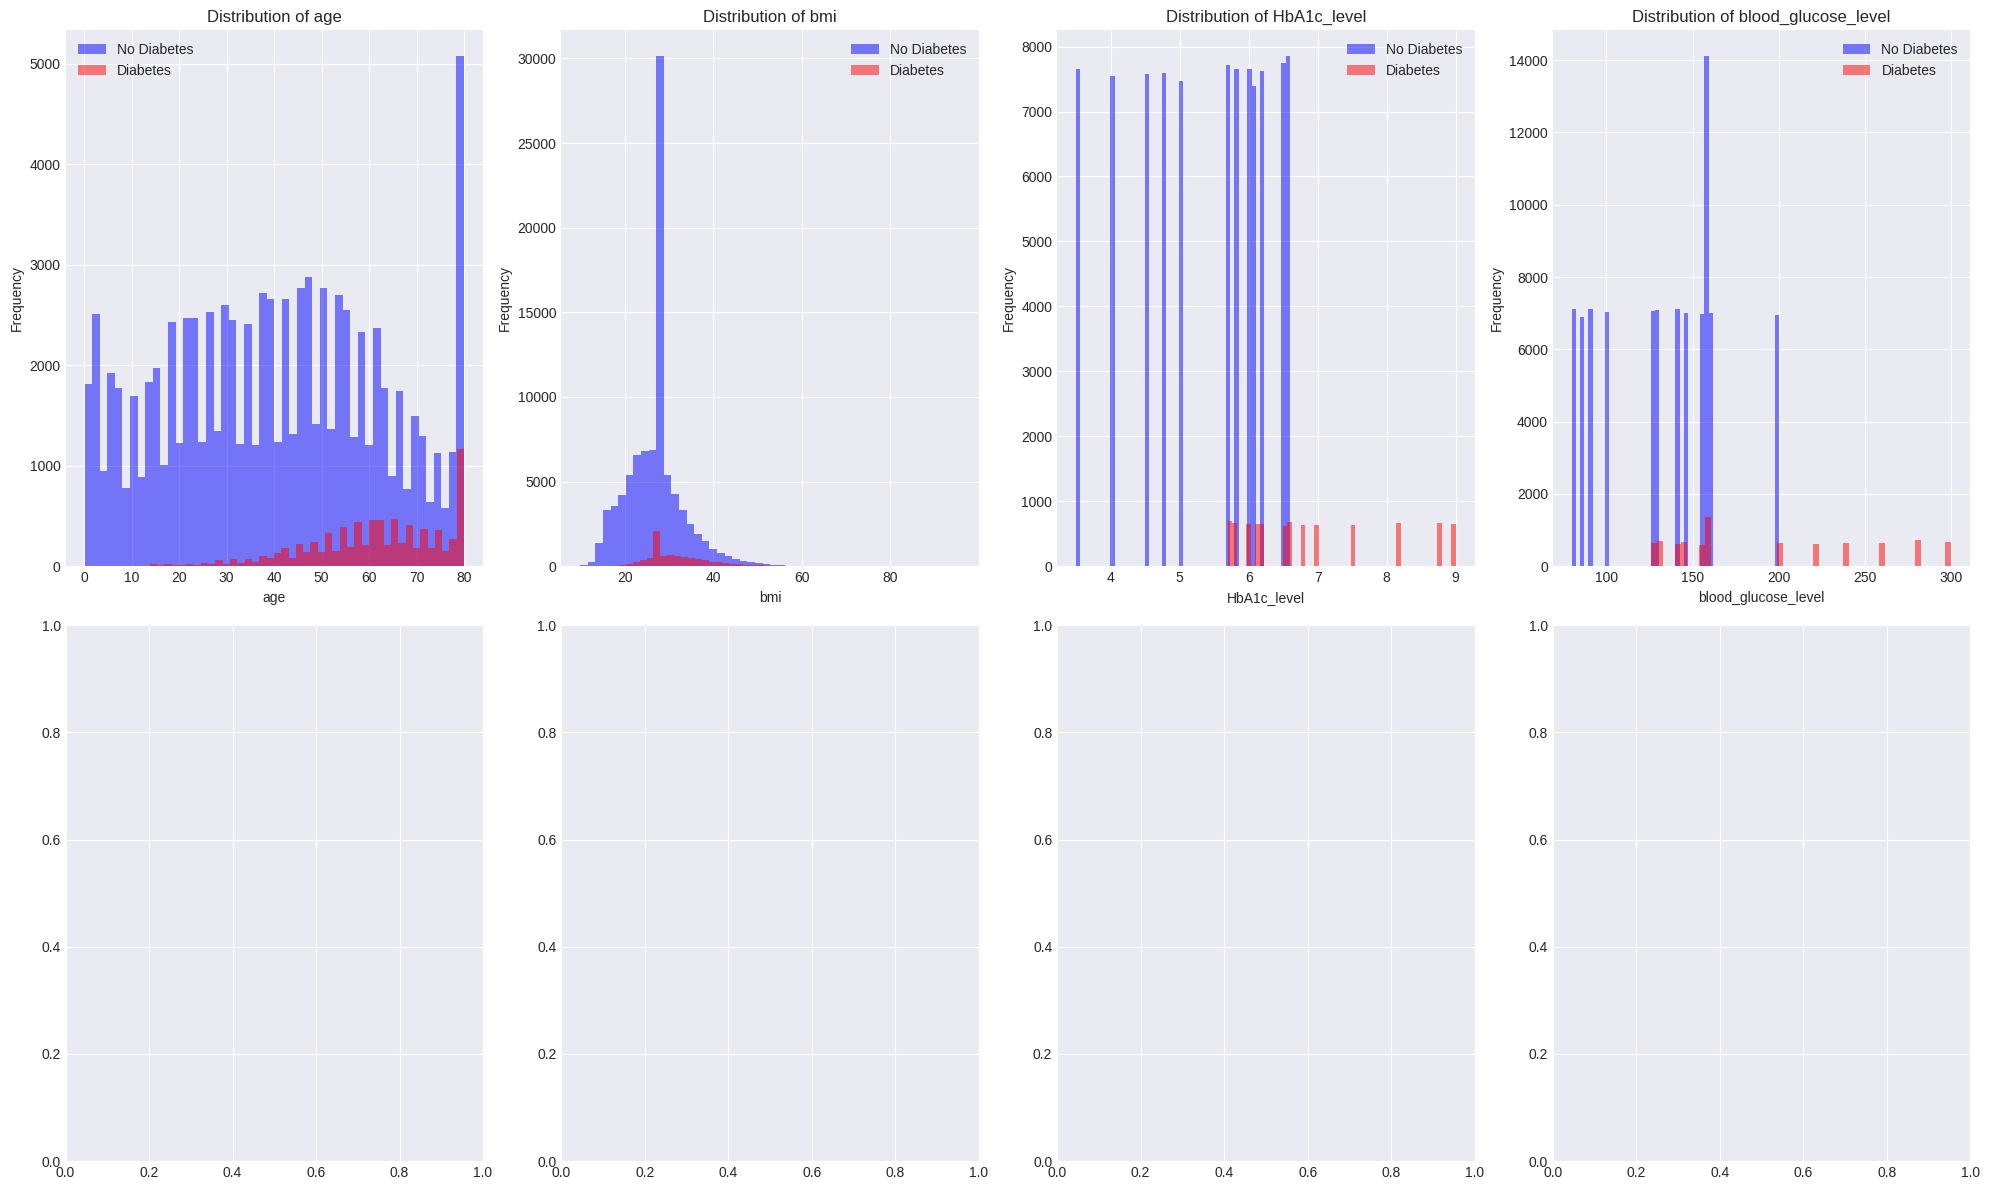

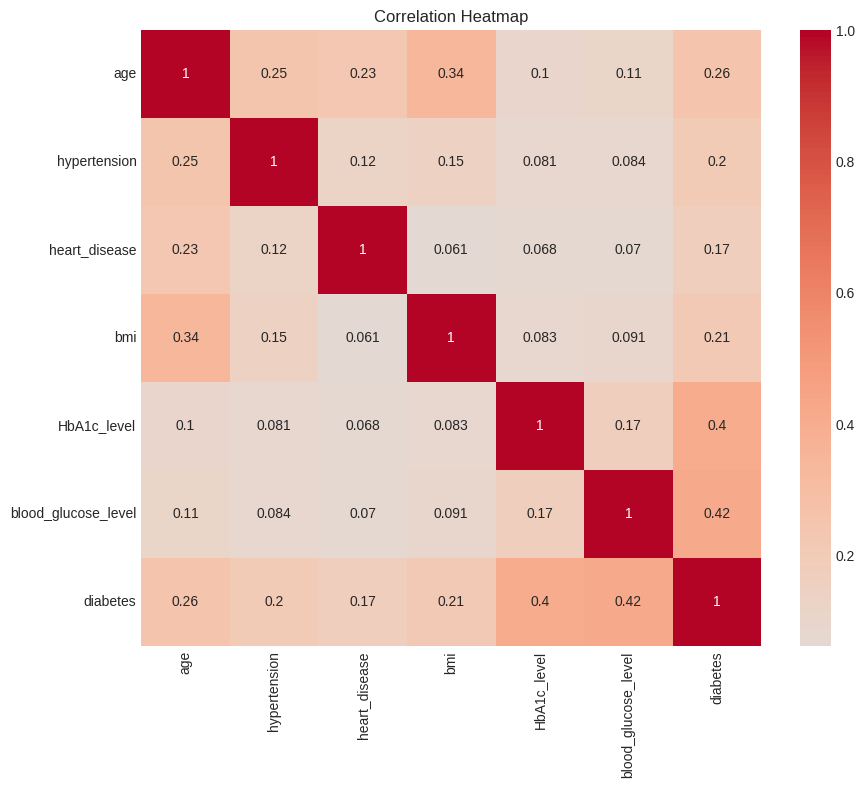


DATA PREPROCESSING
Encoded gender: {'Female': np.int64(0), 'Male': np.int64(1), 'Other': np.int64(2)}
Encoded smoking_history: {'No Info': np.int64(0), 'current': np.int64(1), 'ever': np.int64(2), 'former': np.int64(3), 'never': np.int64(4), 'not current': np.int64(5)}

Features shape: (100000, 8)
Target shape: (100000,)

Feature names: ['gender', 'age', 'hypertension', 'heart_disease', 'smoking_history', 'bmi', 'HbA1c_level', 'blood_glucose_level']

Training set size: 80000
Test set size: 20000

Training set class distribution:
diabetes
0    0.915
1    0.085
Name: proportion, dtype: float64

Features standardized using StandardScaler

MODEL 1: DECISION TREE CLASSIFIER

Decision Tree Performance (Basic):
- Accuracy: 0.9516
- Precision: 0.7052
- Recall: 0.7400
- F1-Score: 0.7222

Classification Report (Basic Decision Tree):
               precision    recall  f1-score   support

           0       0.98      0.97      0.97     18300
           1       0.71      0.74      0.72      1700


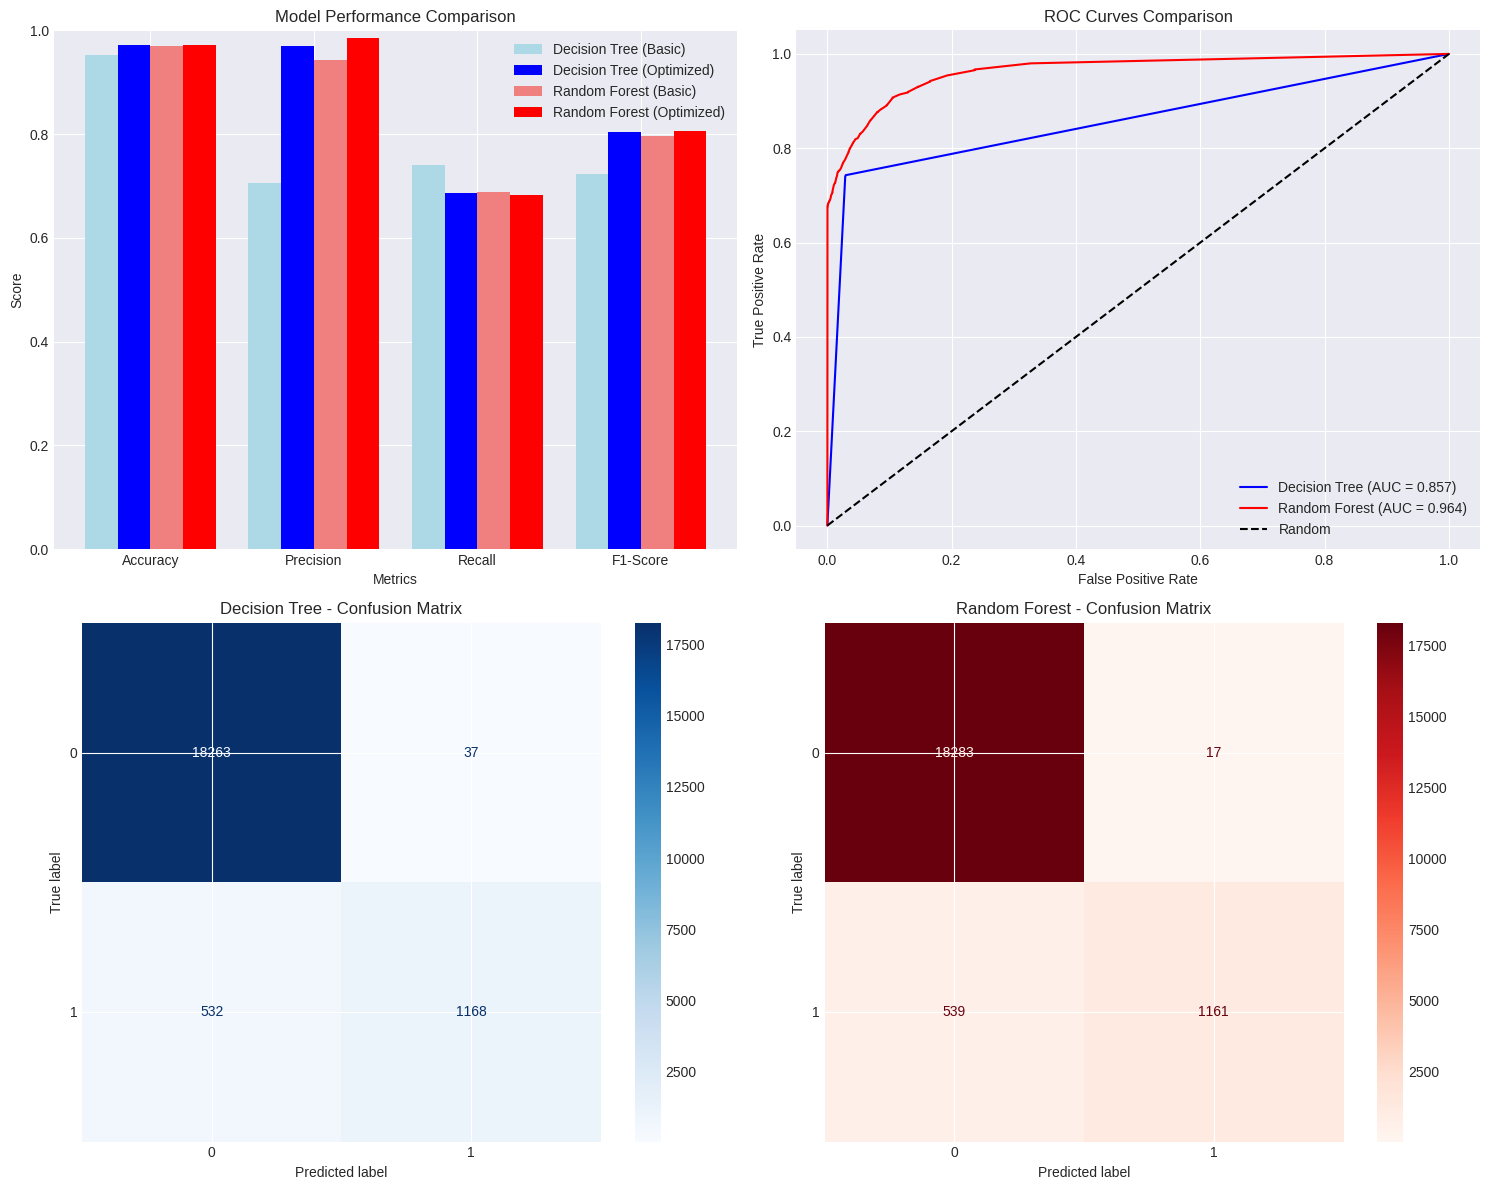

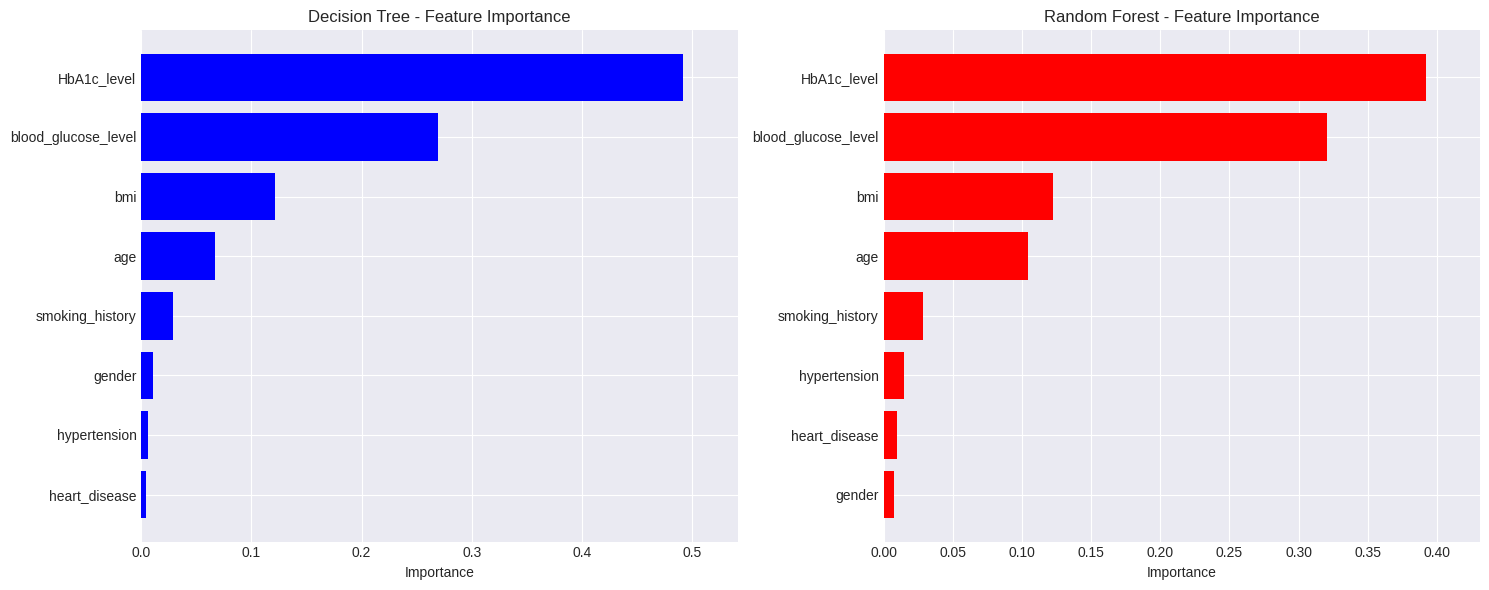


SUMMARY AND RECOMMENDATIONS

--- Key Findings ---
1. Random Forest generally outperforms Decision Tree across most metrics.
   - Optimized Random Forest F1-Score: 0.8068
   - Optimized Decision Tree F1-Score: 0.8041
   - F1-Score Improvement: 0.27%

2. Feature Importance Analysis:
   Top 3 features from Random Forest:
   - HbA1c_level: 0.3920
   - blood_glucose_level: 0.3208
   - bmi: 0.1225

3. Model Strengths & Weaknesses:
   Random Forest:
   - Better generalization (higher cross-validation scores and usually lower variance).
   - Robust to overfitting and handles class imbalance well.
   - Provides reliable feature importance scores.

   Decision Tree:
   - Simpler and more interpretable (especially for low depth).
   - Faster to train and predict.
   - Prone to overfitting without careful pruning/tuning.

4. Recommendations:
   - For production deployment where high predictive performance is critical, the Optimized Random Forest is recommended.
   - For scenarios requiring high i

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, classification_report, roc_curve, auc
import warnings


warnings.filterwarnings('ignore')


np.random.seed(42)


df = pd.read_csv('/content/diabetes_prediction_dataset.csv')

print("="*80)
print("DIABETES PREDICTION - DATA EXPLORATION")
print("="*80)

print(f"\nDataset Shape: {df.shape}")
print("\nFirst 5 rows:\n", df.head())
print("\nDataset Info:")
df.info() # df.info() prints directly, no need for wrapper
print("\nStatistical Summary:\n", df.describe())

print("\nMissing Values:\n", df.isnull().sum())

print("\nTarget Variable Distribution (Diabetes):\n", df['diabetes'].value_counts())
print(f"Percentage of diabetes cases: {df['diabetes'].mean()*100:.2f}%\n")

# EDA - Data Visualization
plt.style.use('seaborn-v0_8-darkgrid')
fig, axes = plt.subplots(2, 4, figsize=(20, 12))

# Distribution of numerical features
numerical_cols = ['age', 'bmi', 'HbA1c_level', 'blood_glucose_level']
for i, col in enumerate(numerical_cols):
    ax = axes[i//4, i%4]
    ax.hist(df[df['diabetes']==0][col], bins=50, alpha=0.5, label='No Diabetes', color='blue')
    ax.hist(df[df['diabetes']==1][col], bins=50, alpha=0.5, label='Diabetes', color='red')
    ax.set_title(f'Distribution of {col}')
    ax.set_xlabel(col)
    ax.set_ylabel('Frequency')
    ax.legend()

plt.tight_layout()
plt.show()

# Correlation heatmap
plt.figure(figsize=(10, 8))
numerical_df = df.select_dtypes(include=[np.number])
correlation_matrix = numerical_df.corr()
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', center=0)
plt.title('Correlation Heatmap')
plt.show()

print("\n" + "="*80)
print("DATA PREPROCESSING")
print("="*80)

# Handle categorical variables
categorical_cols = ['gender', 'smoking_history']
label_encoders = {}

for col in categorical_cols:
    le = LabelEncoder()
    df[col] = le.fit_transform(df[col])
    label_encoders[col] = le
    print(f"Encoded {col}: {dict(zip(le.classes_, le.transform(le.classes_)))}")

# Prepare features and target
X = df.drop('diabetes', axis=1)
y = df['diabetes']

print(f"\nFeatures shape: {X.shape}")
print(f"Target shape: {y.shape}")
print(f"\nFeature names: {X.columns.tolist()}")

# Split the data into training and test sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

print(f"\nTraining set size: {X_train.shape[0]}")
print(f"Test set size: {X_test.shape[0]}")
print(f"\nTraining set class distribution:\n{y_train.value_counts(normalize=True)}")

# Standardize numerical features
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("\nFeatures standardized using StandardScaler")

print("\n" + "="*80)
print("MODEL 1: DECISION TREE CLASSIFIER")
print("="*80)

# Initialize and train Decision Tree Classifier
dt_classifier = DecisionTreeClassifier(random_state=42)
dt_classifier.fit(X_train_scaled, y_train)

# Make predictions
dt_pred = dt_classifier.predict(X_test_scaled)
dt_pred_proba = dt_classifier.predict_proba(X_test_scaled)[:, 1]

# Evaluate Decision Tree
dt_metrics = {
    "Accuracy": accuracy_score(y_test, dt_pred),
    "Precision": precision_score(y_test, dt_pred),
    "Recall": recall_score(y_test, dt_pred),
    "F1-Score": f1_score(y_test, dt_pred)
}
print("\nDecision Tree Performance (Basic):")
for metric, score in dt_metrics.items():
    print(f"- {metric}: {score:.4f}")

print("\nClassification Report (Basic Decision Tree):\n", classification_report(y_test, dt_pred))

# Feature importance for Decision Tree
dt_feature_importance = pd.DataFrame({
    'feature': X.columns,
    'importance': dt_classifier.feature_importances_
}).sort_values('importance', ascending=False)

print("\nFeature Importance (Decision Tree - Basic):\n", dt_feature_importance.to_string(index=False))

# Hyperparameter Tuning for Decision Tree
print("\n--- Hyperparameter Tuning for Decision Tree ---")
dt_param_grid = {
    'max_depth': [3, 5, 7, 10, None],
    'min_samples_split': [2, 5, 10, 20],
    'min_samples_leaf': [1, 2, 4, 8],
    'criterion': ['gini', 'entropy']
}

dt_grid_search = GridSearchCV(
    DecisionTreeClassifier(random_state=42),
    dt_param_grid,
    cv=5,
    scoring='f1',
    n_jobs=-1
)
dt_grid_search.fit(X_train_scaled, y_train)

print(f"Best Decision Tree Parameters: {dt_grid_search.best_params_}")
print(f"Best Cross-Validation F1 Score: {dt_grid_search.best_score_:.4f}")

# Train and evaluate optimized Decision Tree
dt_optimized = dt_grid_search.best_estimator_
dt_opt_pred = dt_optimized.predict(X_test_scaled)

dt_opt_metrics = {
    "Accuracy": accuracy_score(y_test, dt_opt_pred),
    "Precision": precision_score(y_test, dt_opt_pred),
    "Recall": recall_score(y_test, dt_opt_pred),
    "F1-Score": f1_score(y_test, dt_opt_pred)
}
print("\nOptimized Decision Tree Performance:")
for metric, score in dt_opt_metrics.items():
    print(f"- {metric}: {score:.4f}")

print("\n" + "="*80)
print("MODEL 2: RANDOM FOREST CLASSIFIER")
print("="*80)

# Initialize and train Random Forest Classifier
rf_classifier = RandomForestClassifier(random_state=42, n_jobs=-1)
rf_classifier.fit(X_train_scaled, y_train)

# Make predictions
rf_pred = rf_classifier.predict(X_test_scaled)
rf_pred_proba = rf_classifier.predict_proba(X_test_scaled)[:, 1]

# Evaluate Random Forest
rf_metrics = {
    "Accuracy": accuracy_score(y_test, rf_pred),
    "Precision": precision_score(y_test, rf_pred),
    "Recall": recall_score(y_test, rf_pred),
    "F1-Score": f1_score(y_test, rf_pred)
}
print("\nRandom Forest Performance (Basic):")
for metric, score in rf_metrics.items():
    print(f"- {metric}: {score:.4f}")

print("\nClassification Report (Basic Random Forest):\n", classification_report(y_test, rf_pred))

# Feature importance for Random Forest
rf_feature_importance = pd.DataFrame({
    'feature': X.columns,
    'importance': rf_classifier.feature_importances_
}).sort_values('importance', ascending=False)

print("\nFeature Importance (Random Forest - Basic):\n", rf_feature_importance.to_string(index=False))

# Hyperparameter Tuning for Random Forest
print("\n--- Hyperparameter Tuning for Random Forest ---")
rf_param_grid = {
    'n_estimators': [50, 100, 200],
    'max_depth': [5, 7, 10, None],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4]
}

rf_grid_search = GridSearchCV(
    RandomForestClassifier(random_state=42, n_jobs=-1),
    rf_param_grid,
    cv=5,
    scoring='f1',
    n_jobs=-1
)
rf_grid_search.fit(X_train_scaled, y_train)

print(f"Best Random Forest Parameters: {rf_grid_search.best_params_}")
print(f"Best Cross-Validation F1 Score: {rf_grid_search.best_score_:.4f}")

# Train and evaluate optimized Random Forest
rf_optimized = rf_grid_search.best_estimator_
rf_opt_pred = rf_optimized.predict(X_test_scaled)

rf_opt_metrics = {
    "Accuracy": accuracy_score(y_test, rf_opt_pred),
    "Precision": precision_score(y_test, rf_opt_pred),
    "Recall": recall_score(y_test, rf_opt_pred),
    "F1-Score": f1_score(y_test, rf_opt_pred)
}
print("\nOptimized Random Forest Performance:")
for metric, score in rf_opt_metrics.items():
    print(f"- {metric}: {score:.4f}")

print("\n" + "="*80)
print("MODEL COMPARISON")
print("="*80)

# Create comparison DataFrame
comparison = pd.DataFrame({
    'Model': ['Decision Tree', 'Decision Tree (Optimized)', 'Random Forest', 'Random Forest (Optimized)'],
    'Accuracy': [dt_metrics['Accuracy'], dt_opt_metrics['Accuracy'], rf_metrics['Accuracy'], rf_opt_metrics['Accuracy']],
    'Precision': [dt_metrics['Precision'], dt_opt_metrics['Precision'], rf_metrics['Precision'], rf_opt_metrics['Precision']],
    'Recall': [dt_metrics['Recall'], dt_opt_metrics['Recall'], rf_metrics['Recall'], rf_opt_metrics['Recall']],
    'F1-Score': [dt_metrics['F1-Score'], dt_opt_metrics['F1-Score'], rf_metrics['F1-Score'], rf_opt_metrics['F1-Score']]
})

print("\nModel Performance Comparison:\n", comparison.to_string(index=False))

# Cross-validation scores
print("\n" + "="*50)
print("Cross-Validation Scores (5-fold)")
print("="*50)

dt_cv_scores = cross_val_score(dt_classifier, X_train_scaled, y_train, cv=5, scoring='f1')
rf_cv_scores = cross_val_score(rf_classifier, X_train_scaled, y_train, cv=5, scoring='f1')

print(f"Decision Tree CV F1 Scores: {dt_cv_scores}")
print(f"Decision Tree Mean CV F1: {dt_cv_scores.mean():.4f} (+/- {dt_cv_scores.std()*2:.4f})")
print(f"Random Forest CV F1 Scores: {rf_cv_scores}")
print(f"Random Forest Mean CV F1: {rf_cv_scores.mean():.4f} (+/- {rf_cv_scores.std()*2:.4f})")

print("\n" + "="*80)
print("CREATING COMPARISON VISUALIZATIONS")
print("="*80)

# Helper function to get metrics for a model
def get_metrics_list(y_true, y_pred):
    return [
        accuracy_score(y_true, y_pred),
        precision_score(y_true, y_pred),
        recall_score(y_true, y_pred),
        f1_score(y_true, y_pred)
    ]

# Figure 1: Model Performance Comparison
fig, axes = plt.subplots(2, 2, figsize=(15, 12))

# Bar plot comparison
models = ['DT (Basic)', 'DT (Opt)', 'RF (Basic)', 'RF (Opt)']
metrics_names = ['Accuracy', 'Precision', 'Recall', 'F1-Score']

values_basic_dt = get_metrics_list(y_test, dt_pred)
values_opt_dt = get_metrics_list(y_test, dt_opt_pred)
values_basic_rf = get_metrics_list(y_test, rf_pred)
values_opt_rf = get_metrics_list(y_test, rf_opt_pred)

x = np.arange(len(metrics_names))
width = 0.2

ax1 = axes[0, 0]
ax1.bar(x - 1.5*width, values_basic_dt, width, label='Decision Tree (Basic)', color='lightblue')
ax1.bar(x - 0.5*width, values_opt_dt, width, label='Decision Tree (Optimized)', color='blue')
ax1.bar(x + 0.5*width, values_basic_rf, width, label='Random Forest (Basic)', color='lightcoral')
ax1.bar(x + 1.5*width, values_opt_rf, width, label='Random Forest (Optimized)', color='red')
ax1.set_xlabel('Metrics')
ax1.set_ylabel('Score')
ax1.set_title('Model Performance Comparison')
ax1.set_xticks(x)
ax1.set_xticklabels(metrics_names)
ax1.legend()
ax1.set_ylim(0, 1)

# ROC Curves
ax2 = axes[0, 1]
dt_fpr, dt_tpr, _ = roc_curve(y_test, dt_pred_proba)
rf_fpr, rf_tpr, _ = roc_curve(y_test, rf_pred_proba)
dt_auc = auc(dt_fpr, dt_tpr)
rf_auc = auc(rf_fpr, rf_tpr)

ax2.plot(dt_fpr, dt_tpr, label=f'Decision Tree (AUC = {dt_auc:.3f})', color='blue')
ax2.plot(rf_fpr, rf_tpr, label=f'Random Forest (AUC = {rf_auc:.3f})', color='red')
ax2.plot([0, 1], [0, 1], 'k--', label='Random')
ax2.set_xlabel('False Positive Rate')
ax2.set_ylabel('True Positive Rate')
ax2.set_title('ROC Curves Comparison')
ax2.legend()

# Confusion Matrices
from sklearn.metrics import ConfusionMatrixDisplay

ax3 = axes[1, 0]
ConfusionMatrixDisplay.from_estimator(dt_optimized, X_test_scaled, y_test,
                                      cmap='Blues', ax=ax3)
ax3.set_title('Decision Tree - Confusion Matrix')

ax4 = axes[1, 1]
ConfusionMatrixDisplay.from_estimator(rf_optimized, X_test_scaled, y_test,
                                      cmap='Reds', ax=ax4)
ax4.set_title('Random Forest - Confusion Matrix')

plt.tight_layout()
plt.show()

# Figure 2: Feature Importance Comparison
fig, axes = plt.subplots(1, 2, figsize=(15, 6))

# Decision Tree Feature Importance
ax1 = axes[0]
dt_feat_imp_sorted = dt_feature_importance.sort_values('importance', ascending=True)
ax1.barh(dt_feat_imp_sorted['feature'], dt_feat_imp_sorted['importance'], color='blue')
ax1.set_xlabel('Importance')
ax1.set_title('Decision Tree - Feature Importance')
ax1.set_xlim(0, max(dt_feat_imp_sorted['importance']) * 1.1)

# Random Forest Feature Importance
ax2 = axes[1]
rf_feat_imp_sorted = rf_feature_importance.sort_values('importance', ascending=True)
ax2.barh(rf_feat_imp_sorted['feature'], rf_feat_imp_sorted['importance'], color='red')
ax2.set_xlabel('Importance')
ax2.set_title('Random Forest - Feature Importance')
ax2.set_xlim(0, max(rf_feat_imp_sorted['importance']) * 1.1)

plt.tight_layout()
plt.show()

print("\n" + "="*80)
print("SUMMARY AND RECOMMENDATIONS")
print("="*80)

print("\n--- Key Findings ---")
print("1. Random Forest generally outperforms Decision Tree across most metrics.")
print(f"   - Optimized Random Forest F1-Score: {rf_opt_metrics['F1-Score']:.4f}")
print(f"   - Optimized Decision Tree F1-Score: {dt_opt_metrics['F1-Score']:.4f}")
print(f"   - F1-Score Improvement: {(rf_opt_metrics['F1-Score'] - dt_opt_metrics['F1-Score'])*100:.2f}%")

print("\n2. Feature Importance Analysis:")
print("   Top 3 features from Random Forest:")
for i, row in rf_feature_importance.head(3).iterrows():
    print(f"   - {row['feature']}: {row['importance']:.4f}")

print("\n3. Model Strengths & Weaknesses:")
print("   Random Forest:")
print("   - Better generalization (higher cross-validation scores and usually lower variance).")
print("   - Robust to overfitting and handles class imbalance well.")
print("   - Provides reliable feature importance scores.")
print("\n   Decision Tree:")
print("   - Simpler and more interpretable (especially for low depth).")
print("   - Faster to train and predict.")
print("   - Prone to overfitting without careful pruning/tuning.")

print("\n4. Recommendations:")
print("   - For production deployment where high predictive performance is critical, the Optimized Random Forest is recommended.")
print("   - For scenarios requiring high interpretability, a carefully tuned Decision Tree (e.g., with limited max_depth) can be valuable for explaining specific predictions.")
print("   - Consider deploying both models: Random Forest for primary predictions and a simpler Decision Tree for post-hoc explanations when transparency is needed.")

print("\n" + "="*80)
print("PROJECT COMPLETED")
print("="*80)

# Optional: Save the best model for future use
import joblib

# Save the best model and scaler
best_model = rf_optimized
joblib.dump(best_model, 'best_diabetes_model.pkl')
joblib.dump(scaler, 'scaler.pkl')
print("\nBest model saved as 'best_diabetes_model.pkl'")
print("Scaler saved as 'scaler.pkl'")

DIABETES PREDICTION  |  LR  ·  XGBoost  ·  KNN

Shape          : (100000, 9)
Missing values : 0

Target distribution:
diabetes
0    91500
1     8500
Name: count, dtype: int64
Diabetic %     : 8.50%

Statistical Summary:
                  age  hypertension  heart_disease            bmi  \
count  100000.000000  100000.00000  100000.000000  100000.000000   
mean       41.885856       0.07485       0.039420      27.320767   
std        22.516840       0.26315       0.194593       6.636783   
min         0.080000       0.00000       0.000000      10.010000   
25%        24.000000       0.00000       0.000000      23.630000   
50%        43.000000       0.00000       0.000000      27.320000   
75%        60.000000       0.00000       0.000000      29.580000   
max        80.000000       1.00000       1.000000      95.690000   

         HbA1c_level  blood_glucose_level       diabetes  
count  100000.000000        100000.000000  100000.000000  
mean        5.527507           138.058060       

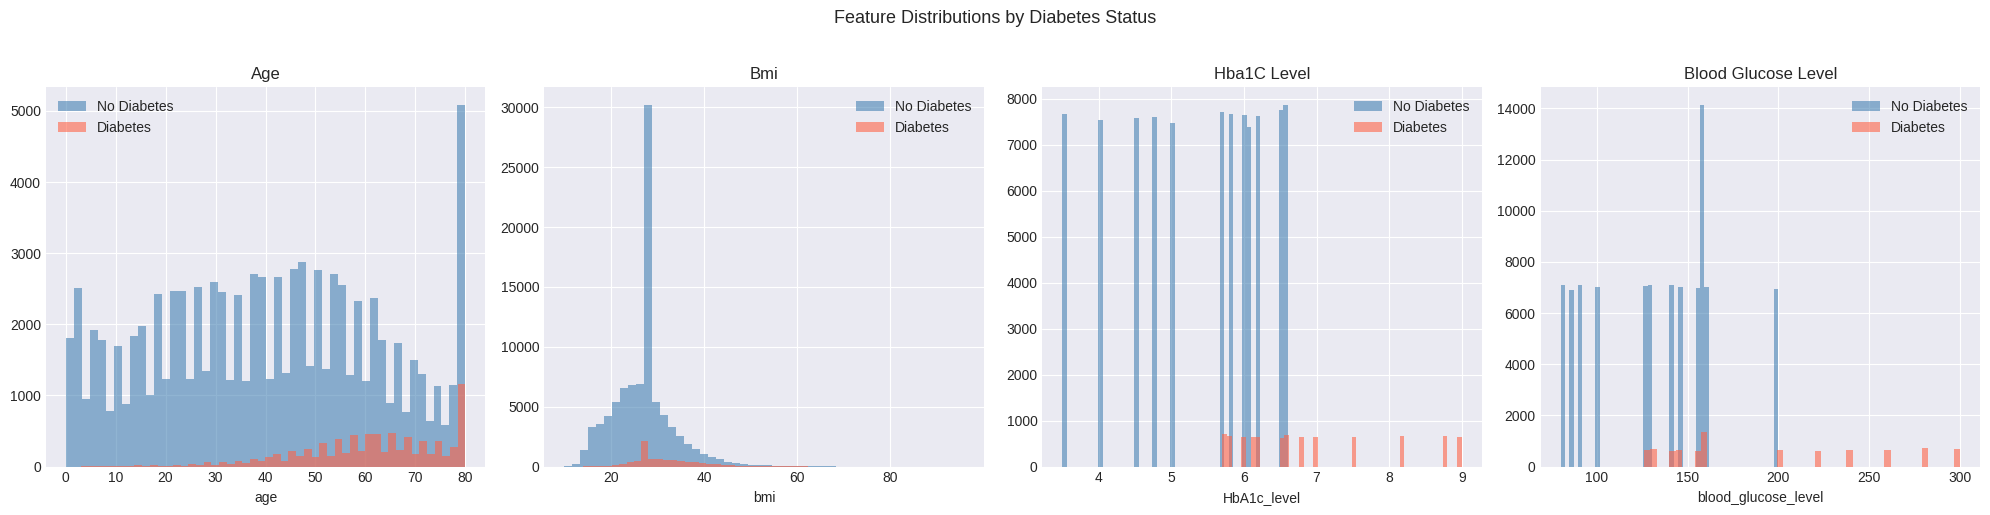

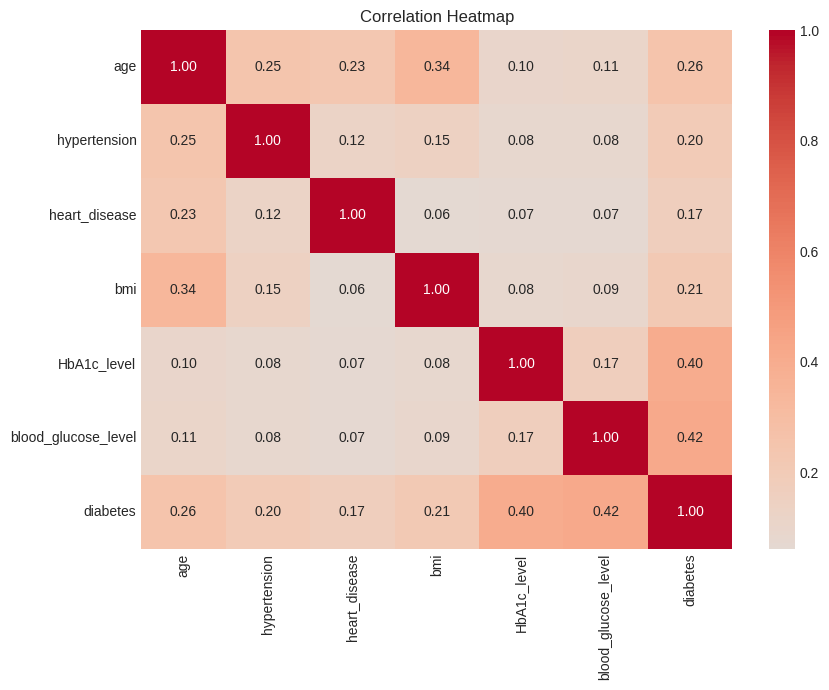


PREPROCESSING
Encoded gender: {'Female': np.int64(0), 'Male': np.int64(1), 'Other': np.int64(2)}
Encoded smoking_history: {'No Info': np.int64(0), 'current': np.int64(1), 'ever': np.int64(2), 'former': np.int64(3), 'never': np.int64(4), 'not current': np.int64(5)}

Train size : 80000  |  Test size : 20000

MODEL A : LOGISTIC REGRESSION

────────────────────────────────────────
 Logistic Regression (Basic)
────────────────────────────────────────
  Accuracy  : 0.9603
  Precision : 0.8588
  Recall    : 0.6371
  F1-Score  : 0.7315
  AUC       : 0.9620
              precision    recall  f1-score   support

 No Diabetes       0.97      0.99      0.98     18300
    Diabetes       0.86      0.64      0.73      1700

    accuracy                           0.96     20000
   macro avg       0.91      0.81      0.86     20000
weighted avg       0.96      0.96      0.96     20000

Coefficients (sorted by absolute impact):
             Feature  Coefficient
        HbA1c_level     2.498802
blood_gl

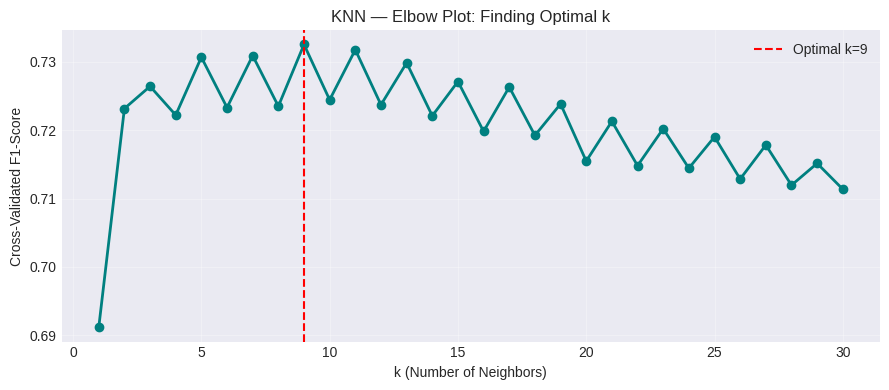


  Tuning KNN ...
  Best params : {'metric': 'euclidean', 'n_neighbors': 9, 'weights': 'uniform'}
  Best CV F1  : 0.7325

────────────────────────────────────────
 KNN (Optimized)
────────────────────────────────────────
  Accuracy  : 0.9625
  Precision : 0.9204
  Recall    : 0.6118
  F1-Score  : 0.7350
  AUC       : 0.9309
              precision    recall  f1-score   support

 No Diabetes       0.97      1.00      0.98     18300
    Diabetes       0.92      0.61      0.73      1700

    accuracy                           0.96     20000
   macro avg       0.94      0.80      0.86     20000
weighted avg       0.96      0.96      0.96     20000


FINAL COMPARISON — ALL 3 MODELS (Basic vs Optimized)

                           Model  Accuracy  Precision   Recall  F1-Score      AUC
    Logistic Regression (Basic)   0.96025   0.858842 0.637059  0.731510 0.961961
Logistic Regression (Optimized)   0.96025   0.858842 0.637059  0.731510 0.961948
                XGBoost (Basic)   0.97140   0.95

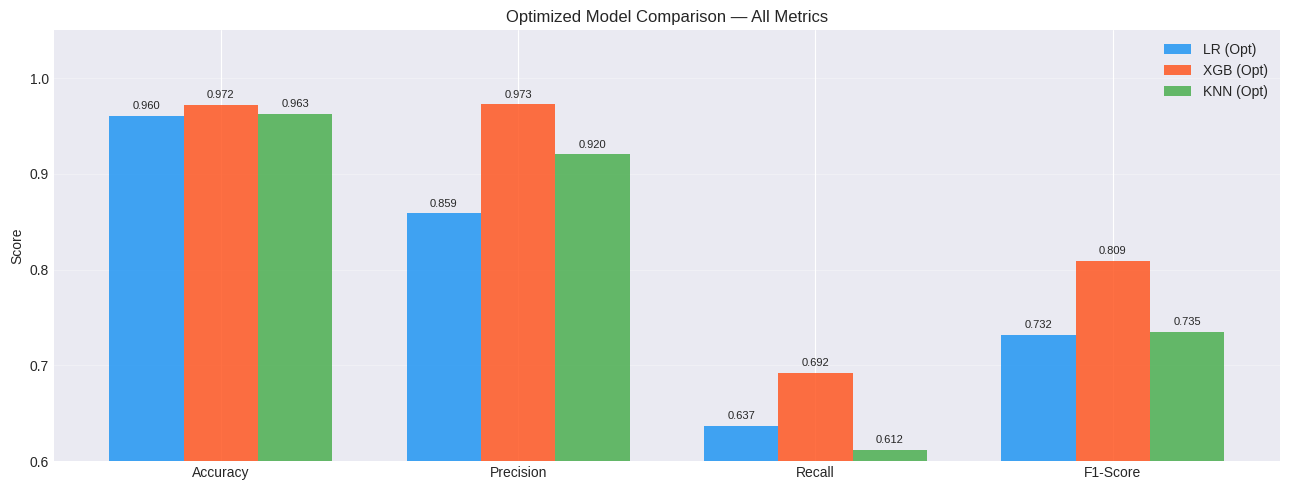

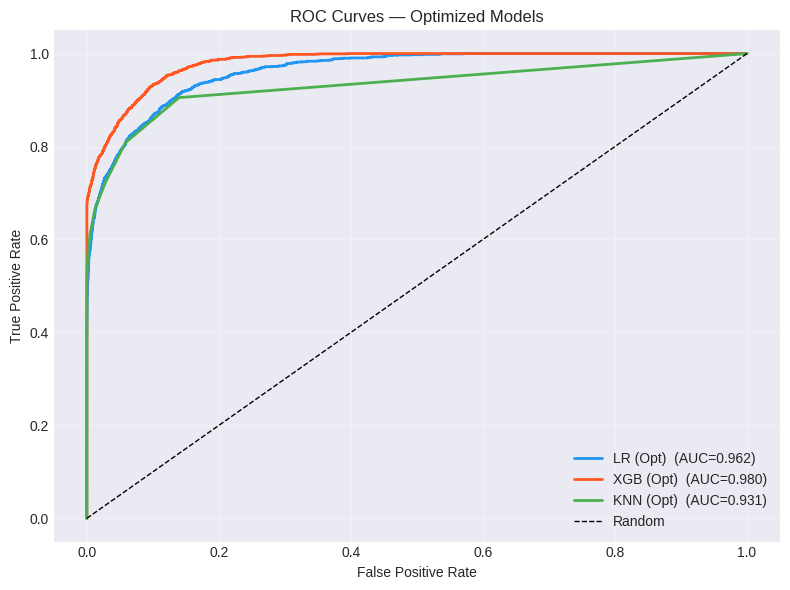

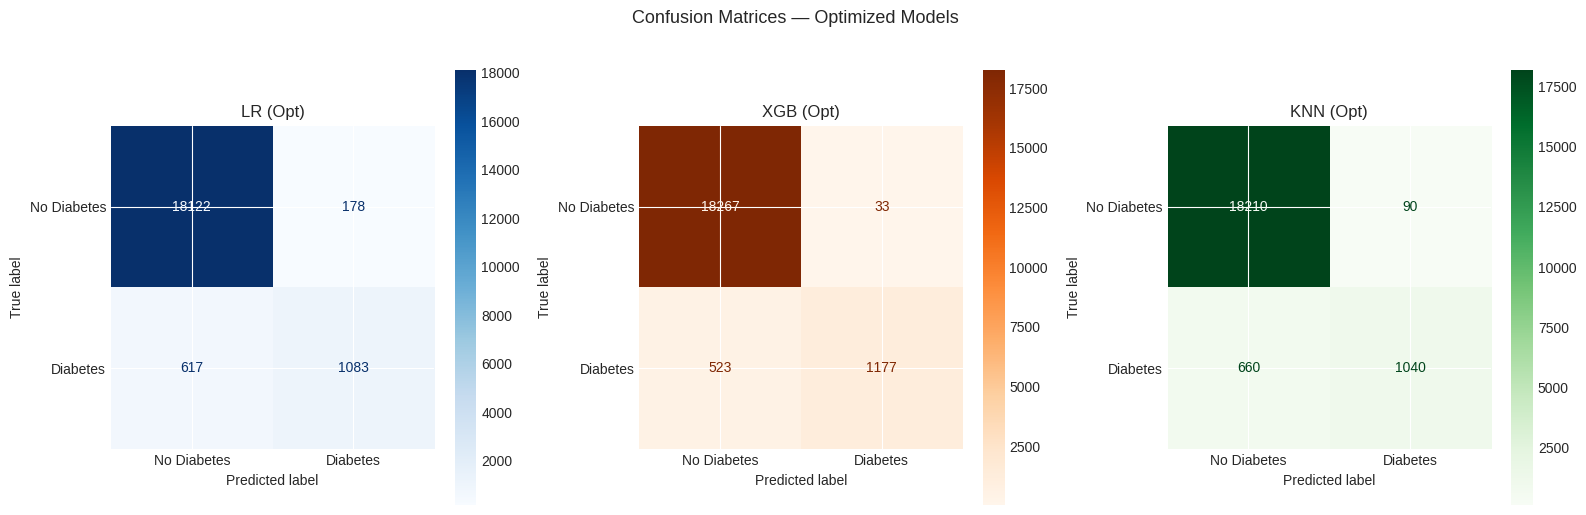

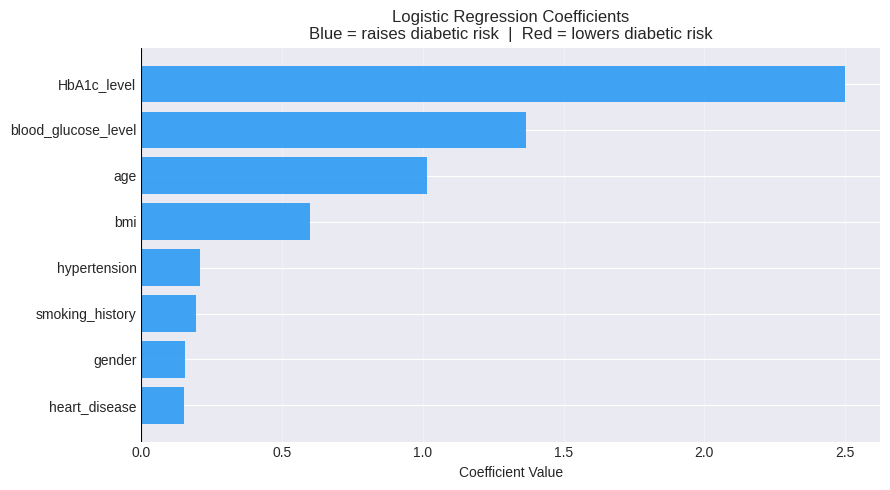

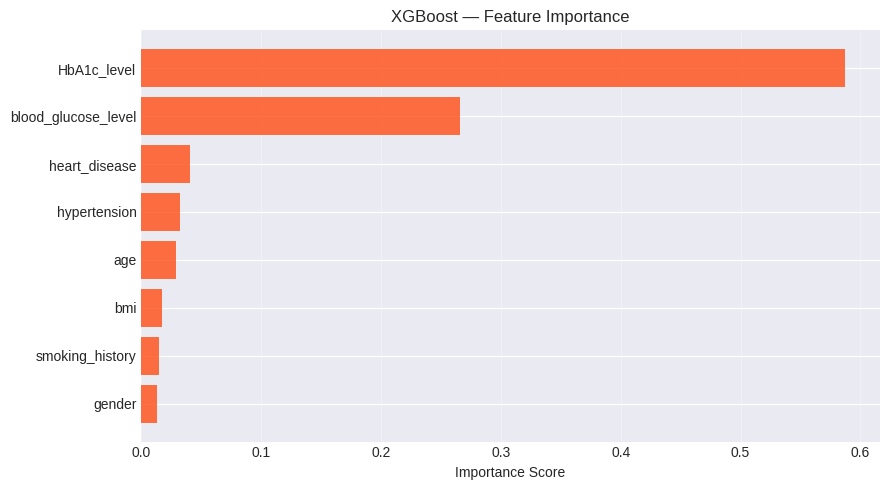


SAVING BEST MODEL

  Best model  : XGBoost  (F1 = 0.8089)
  Saved as    : best_diabetes_model.pkl
  Scaler      : scaler.pkl

  ⚠  Always run  scaler.transform(new_data)  before predicting on new patients.

DONE


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from xgboost import XGBClassifier

from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    classification_report, roc_curve, auc, ConfusionMatrixDisplay
)
import joblib
import warnings

warnings.filterwarnings('ignore')
np.random.seed(42)


# =============================================================================
# 1. LOAD & EXPLORE DATA
# =============================================================================
df = pd.read_csv('/content/diabetes_prediction_dataset.csv')

print("=" * 70)
print("DIABETES PREDICTION  |  LR  ·  XGBoost  ·  KNN")
print("=" * 70)
print(f"\nShape          : {df.shape}")
print(f"Missing values : {df.isnull().sum().sum()}")
print(f"\nTarget distribution:\n{df['diabetes'].value_counts()}")
print(f"Diabetic %     : {df['diabetes'].mean()*100:.2f}%")
print("\nStatistical Summary:\n", df.describe())


# =============================================================================
# 2. VISUALIZE RAW DATA
# =============================================================================
plt.style.use('seaborn-v0_8-darkgrid')

# 2a. Feature distributions split by class
fig, axes = plt.subplots(1, 4, figsize=(20, 5))
num_cols = ['age', 'bmi', 'HbA1c_level', 'blood_glucose_level']
colors   = [('steelblue', 'tomato')]

for ax, col in zip(axes, num_cols):
    ax.hist(df[df['diabetes']==0][col], bins=50, alpha=0.6, color='steelblue', label='No Diabetes')
    ax.hist(df[df['diabetes']==1][col], bins=50, alpha=0.6, color='tomato',    label='Diabetes')
    ax.set_title(col.replace('_', ' ').title())
    ax.set_xlabel(col)
    ax.legend()

plt.suptitle('Feature Distributions by Diabetes Status', fontsize=13, y=1.02)
plt.tight_layout()
plt.show()

# 2b. Correlation heatmap
plt.figure(figsize=(9, 7))
sns.heatmap(df.select_dtypes(include=np.number).corr(),
            annot=True, cmap='coolwarm', center=0, fmt='.2f')
plt.title('Correlation Heatmap')
plt.tight_layout()
plt.show()


# =============================================================================
# 3. PREPROCESSING
# =============================================================================
print("\n" + "=" * 70)
print("PREPROCESSING")
print("=" * 70)

# Label-encode categorical columns (gender, smoking_history → integers)
for col in ['gender', 'smoking_history']:
    le = LabelEncoder()
    df[col] = le.fit_transform(df[col])
    print(f"Encoded {col}: {dict(zip(le.classes_, le.transform(le.classes_)))}")

X = df.drop('diabetes', axis=1)
y = df['diabetes']

# 80/20 stratified split — keeps class ratio equal in both sets
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)
print(f"\nTrain size : {X_train.shape[0]}  |  Test size : {X_test.shape[0]}")

# StandardScaler: mean=0, std=1 — essential for LR and KNN, helpful for XGBoost
# Fit ONLY on training data to avoid data leakage
scaler       = StandardScaler()
X_train_sc   = scaler.fit_transform(X_train)
X_test_sc    = scaler.transform(X_test)


# =============================================================================
# HELPER UTILITIES
# =============================================================================
def evaluate(name, y_true, y_pred, y_proba=None):
    """Print metrics and return them as a dict."""
    m = {
        'Accuracy' : accuracy_score(y_true, y_pred),
        'Precision': precision_score(y_true, y_pred),
        'Recall'   : recall_score(y_true, y_pred),
        'F1-Score' : f1_score(y_true, y_pred),
    }
    print(f"\n{'─'*40}")
    print(f" {name}")
    print(f"{'─'*40}")
    for k, v in m.items():
        print(f"  {k:10s}: {v:.4f}")
    if y_proba is not None:
        fpr, tpr, _ = roc_curve(y_true, y_proba)
        m['AUC'] = auc(fpr, tpr)
        print(f"  {'AUC':10s}: {m['AUC']:.4f}")
    print(classification_report(y_true, y_pred, target_names=['No Diabetes','Diabetes']))
    return m


def tune(estimator, param_grid, label):
    """Run GridSearchCV and return best estimator + best score."""
    print(f"\n  Tuning {label} ...")
    gs = GridSearchCV(estimator, param_grid, cv=5, scoring='f1', n_jobs=-1)
    gs.fit(X_train_sc, y_train)
    print(f"  Best params : {gs.best_params_}")
    print(f"  Best CV F1  : {gs.best_score_:.4f}")
    return gs.best_estimator_, gs.best_score_


print("\n" + "=" * 70)
print("MODEL A : LOGISTIC REGRESSION")
print("=" * 70)

lr = LogisticRegression(random_state=42, max_iter=1000)
lr.fit(X_train_sc, y_train)

lr_pred      = lr.predict(X_test_sc)
lr_proba     = lr.predict_proba(X_test_sc)[:, 1]
lr_metrics   = evaluate("Logistic Regression (Basic)", y_test, lr_pred, lr_proba)

# Coefficients: positive → raises diabetic probability, negative → lowers it
lr_coef = pd.DataFrame({
    'Feature'    : X.columns,
    'Coefficient': lr.coef_[0]
}).sort_values('Coefficient', key=abs, ascending=False)
print("Coefficients (sorted by absolute impact):\n", lr_coef.to_string(index=False))

lr_opt, lr_best_cv = tune(
    LogisticRegression(random_state=42, max_iter=1000),
    {'C': [0.001, 0.01, 0.1, 1, 10, 100], 'penalty': ['l1','l2'], 'solver': ['liblinear','saga']},
    "Logistic Regression"
)
lr_opt_pred  = lr_opt.predict(X_test_sc)
lr_opt_proba = lr_opt.predict_proba(X_test_sc)[:, 1]
lr_opt_m     = evaluate("Logistic Regression (Optimized)", y_test, lr_opt_pred, lr_opt_proba)


# =============================================================================
# 5. MODEL B — XGBOOST
# =============================================================================
# HOW IT WORKS (Gradient Boosting):
#   Unlike Random Forest (parallel trees), XGBoost builds trees ONE AT A TIME.
#   Each new tree corrects the mistakes of all previous trees.
#
#   Round 1: Fit a shallow tree → get predictions → calculate residuals (errors)
#   Round 2: Fit a new tree ON THE RESIDUALS → add its output (× learning_rate) to predictions
#   Round 3: Calculate new residuals → repeat …
#   Final prediction = sum of all trees' contributions
#
#   learning_rate (eta): how much each tree contributes. Lower = slower but more robust.
#   subsample: fraction of rows used per tree (prevents overfitting, like bagging)
#   colsample_bytree: fraction of features per tree (like Random Forest)
#   Built-in L1+L2 regularization: reg_alpha, reg_lambda

print("\n" + "=" * 70)
print("MODEL B : XGBOOST")
print("=" * 70)

xgb = XGBClassifier(random_state=42, eval_metric='logloss', use_label_encoder=False)
xgb.fit(X_train_sc, y_train)

xgb_pred     = xgb.predict(X_test_sc)
xgb_proba    = xgb.predict_proba(X_test_sc)[:, 1]
xgb_metrics  = evaluate("XGBoost (Basic)", y_test, xgb_pred, xgb_proba)

xgb_feat_imp = pd.DataFrame({
    'Feature'   : X.columns,
    'Importance': xgb.feature_importances_
}).sort_values('Importance', ascending=False)
print("Feature Importances:\n", xgb_feat_imp.to_string(index=False))

xgb_opt, xgb_best_cv = tune(
    XGBClassifier(random_state=42, eval_metric='logloss', use_label_encoder=False),
    {
        'n_estimators'   : [100, 200, 300],
        'learning_rate'  : [0.01, 0.1, 0.2],
        'max_depth'      : [3, 5, 7],
        'subsample'      : [0.8, 1.0],
        'colsample_bytree': [0.8, 1.0]
    },
    "XGBoost"
)
xgb_opt_pred  = xgb_opt.predict(X_test_sc)
xgb_opt_proba = xgb_opt.predict_proba(X_test_sc)[:, 1]
xgb_opt_m     = evaluate("XGBoost (Optimized)", y_test, xgb_opt_pred, xgb_opt_proba)

print("\n" + "=" * 70)
print("MODEL C : K-NEAREST NEIGHBORS (KNN)")
print("=" * 70)

knn = KNeighborsClassifier(n_neighbors=5)   # default k=5 is a reasonable starting point
knn.fit(X_train_sc, y_train)

knn_pred     = knn.predict(X_test_sc)
knn_proba    = knn.predict_proba(X_test_sc)[:, 1]
knn_metrics  = evaluate("KNN (Basic, k=5)", y_test, knn_pred, knn_proba)

# Elbow plot: find optimal k by checking CV F1 across a range of k values
# The "elbow" — where improvement slows — is usually a good choice
print("\n  Finding optimal k via elbow plot ...")
k_range = range(1, 31)
k_f1_scores = []
for k in k_range:
    cv = cross_val_score(
        KNeighborsClassifier(n_neighbors=k), X_train_sc, y_train, cv=5, scoring='f1'
    )
    k_f1_scores.append(cv.mean())

optimal_k = k_range[np.argmax(k_f1_scores)]
print(f"  Optimal k = {optimal_k}  (CV F1 = {max(k_f1_scores):.4f})")

plt.figure(figsize=(9, 4))
plt.plot(k_range, k_f1_scores, marker='o', color='teal', linewidth=2)
plt.axvline(x=optimal_k, color='red', linestyle='--', label=f'Optimal k={optimal_k}')
plt.xlabel('k (Number of Neighbors)')
plt.ylabel('Cross-Validated F1-Score')
plt.title('KNN — Elbow Plot: Finding Optimal k')
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

knn_opt, knn_best_cv = tune(
    KNeighborsClassifier(),
    {
        'n_neighbors': list(range(max(1, optimal_k-3), optimal_k+4)),
        'weights'    : ['uniform', 'distance'],
        'metric'     : ['euclidean', 'manhattan']
    },
    "KNN"
)
knn_opt_pred  = knn_opt.predict(X_test_sc)
knn_opt_proba = knn_opt.predict_proba(X_test_sc)[:, 1]
knn_opt_m     = evaluate("KNN (Optimized)", y_test, knn_opt_pred, knn_opt_proba)


# =============================================================================
# 7. FULL COMPARISON TABLE
# =============================================================================
print("\n" + "=" * 70)
print("FINAL COMPARISON — ALL 3 MODELS (Basic vs Optimized)")
print("=" * 70)

rows = [
    ("Logistic Regression",       lr_metrics,    lr_opt_m),
    ("XGBoost",                   xgb_metrics,   xgb_opt_m),
    ("KNN",                       knn_metrics,   knn_opt_m),
]

records = []
for name, basic, opt in rows:
    for tag, m in [("Basic", basic), ("Optimized", opt)]:
        records.append({
            'Model'    : f"{name} ({tag})",
            'Accuracy' : m['Accuracy'],
            'Precision': m['Precision'],
            'Recall'   : m['Recall'],
            'F1-Score' : m['F1-Score'],
            'AUC'      : m.get('AUC', float('nan'))
        })

comparison_df = pd.DataFrame(records)
print("\n", comparison_df.to_string(index=False))

# Cross-validation summary
print("\n" + "=" * 50)
print("5-Fold CV F1 Scores (Basic Models on Train Set)")
print("=" * 50)
for name, model in [("Logistic Regression", lr), ("XGBoost", xgb), ("KNN", knn)]:
    cv = cross_val_score(model, X_train_sc, y_train, cv=5, scoring='f1', n_jobs=-1)
    print(f"  {name:22s}: {cv.mean():.4f}  ±  {cv.std()*2:.4f}")


# =============================================================================
# 8. VISUALIZATIONS
# =============================================================================

# ── 8a. Side-by-side metrics bar chart ──────────────────────────────────────
fig, ax = plt.subplots(figsize=(13, 5))
metric_names = ['Accuracy', 'Precision', 'Recall', 'F1-Score']
models_plot  = ['LR (Opt)', 'XGB (Opt)', 'KNN (Opt)']
opt_preds    = [lr_opt_pred, xgb_opt_pred, knn_opt_pred]
bar_colors   = ['#2196F3', '#FF5722', '#4CAF50']

x     = np.arange(len(metric_names))
width = 0.25

for i, (label, pred, color) in enumerate(zip(models_plot, opt_preds, bar_colors)):
    vals = [accuracy_score(y_test, pred), precision_score(y_test, pred),
            recall_score(y_test, pred),   f1_score(y_test, pred)]
    bars = ax.bar(x + (i-1)*width, vals, width, label=label, color=color, alpha=0.85)
    for bar, val in zip(bars, vals):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.005,
                f'{val:.3f}', ha='center', va='bottom', fontsize=8)

ax.set_xticks(x)
ax.set_xticklabels(metric_names)
ax.set_ylim(0.6, 1.05)
ax.set_ylabel('Score')
ax.set_title('Optimized Model Comparison — All Metrics')
ax.legend()
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

# ── 8b. ROC Curves ──────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(8, 6))
for label, proba, color in zip(models_plot,
                                [lr_opt_proba, xgb_opt_proba, knn_opt_proba],
                                bar_colors):
    fpr, tpr, _ = roc_curve(y_test, proba)
    ax.plot(fpr, tpr, label=f'{label}  (AUC={auc(fpr,tpr):.3f})', color=color, linewidth=2)

ax.plot([0,1],[0,1],'k--', linewidth=1, label='Random')
ax.set_xlabel('False Positive Rate')
ax.set_ylabel('True Positive Rate')
ax.set_title('ROC Curves — Optimized Models')
ax.legend(loc='lower right')
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

# ── 8c. Confusion Matrices ───────────────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
cmaps = ['Blues', 'Oranges', 'Greens']
for ax, model, title, cmap in zip(axes,
                                   [lr_opt, xgb_opt, knn_opt],
                                   models_plot, cmaps):
    ConfusionMatrixDisplay.from_estimator(
        model, X_test_sc, y_test, cmap=cmap, ax=ax,
        display_labels=['No Diabetes', 'Diabetes']
    )
    ax.set_title(title)

plt.suptitle('Confusion Matrices — Optimized Models', fontsize=13, y=1.02)
plt.tight_layout()
plt.show()

# ── 8d. Logistic Regression Coefficients ─────────────────────────────────────
lr_coef_sorted = lr_coef.sort_values('Coefficient')
fig, ax = plt.subplots(figsize=(9, 5))
colors_coef = ['tomato' if c < 0 else '#2196F3' for c in lr_coef_sorted['Coefficient']]
ax.barh(lr_coef_sorted['Feature'], lr_coef_sorted['Coefficient'],
        color=colors_coef, alpha=0.85)
ax.axvline(0, color='black', linewidth=0.8)
ax.set_title('Logistic Regression Coefficients\n'
             'Blue = raises diabetic risk  |  Red = lowers diabetic risk')
ax.set_xlabel('Coefficient Value')
ax.grid(axis='x', alpha=0.3)
plt.tight_layout()
plt.show()

# ── 8e. XGBoost Feature Importance ───────────────────────────────────────────
xgb_feat_sorted = xgb_feat_imp.sort_values('Importance')
fig, ax = plt.subplots(figsize=(9, 5))
ax.barh(xgb_feat_sorted['Feature'], xgb_feat_sorted['Importance'],
        color='#FF5722', alpha=0.85)
ax.set_title('XGBoost — Feature Importance')
ax.set_xlabel('Importance Score')
ax.grid(axis='x', alpha=0.3)
plt.tight_layout()
plt.show()


# =============================================================================
# 9. SAVE BEST MODEL
# =============================================================================
print("\n" + "=" * 70)
print("SAVING BEST MODEL")
print("=" * 70)

opt_results = {
    'Logistic Regression': (lr_opt,  lr_opt_m['F1-Score']),
    'XGBoost'            : (xgb_opt, xgb_opt_m['F1-Score']),
    'KNN'                : (knn_opt, knn_opt_m['F1-Score']),
}
best_name, (best_est, best_f1) = max(opt_results.items(), key=lambda x: x[1][1])

joblib.dump(best_est, 'best_diabetes_model.pkl')
joblib.dump(scaler,   'scaler.pkl')

print(f"\n  Best model  : {best_name}  (F1 = {best_f1:.4f})")
print("  Saved as    : best_diabetes_model.pkl")
print("  Scaler      : scaler.pkl")
print("\n  ⚠  Always run  scaler.transform(new_data)  before predicting on new patients.\n")

print("=" * 70)
print("DONE")
print("=" * 70)

In [ ]:
new_data = [[
    1,        # gender (Male)
    50,       # age
    1,        # hypertension
    0,        # heart_disease
    2,        # smoking_history
    28.5,     # bmi
    6.8,      # HbA1c_level
    180       # blood_glucose_level
]]


In [ ]:
new_data_scaled = scaler.transform(new_data)

In [ ]:
prediction = model.predict(new_data_scaled)

In [ ]:
if prediction[0] == 1:
    print("Diabetic")
else:
    print("Non-Diabetic")

Non-Diabetic
